In [40]:
import torch
import torch.nn as nn
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms.v2 as v2
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.optim as optim


### Data Aquisition

In [18]:
training_set = torchvision.datasets.MNIST(
    root = "data",
    train = True,
    transform = v2.Compose([v2.ToImage(),v2.ToDtype(torch.float32,scale=True)])
)

In [19]:
batch_size = 64
loaded_set = DataLoader(
    dataset= training_set,
    batch_size= batch_size,
    shuffle= True
)

### Neural Network

In [49]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

        self.decoder = nn.Sequential(
            nn.Linear(10, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256,784)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)

        latent = self.encoder(x)
        reconstruct = self.decoder(latent)
        return latent, reconstruct
    
model = Autoencoder().to(device="cpu")
print(model)



Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
  )
)


### Training

In [21]:
optimizer = optim.Adam(params=model.parameters(),lr = 1e-3)
loss_fn = nn.MSELoss()

In [39]:
def train(dataloader,model,loss_fn,optimizer):
    total_loss = 0
    for X, _ in dataloader:
        X = X.to("cpu")
        latent , reconstruct = model(X)
        X_flat = X.view(X.size(0),-1)

        loss = loss_fn(reconstruct, X_flat)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    print(f"Loss is: {total_loss/len(dataloader):<4f}")


In [ ]:
epochs = 20
for i in range(epochs):
    train(loaded_set,model,loss_fn,optimizer)
    print(f"Epoch:{i+1}/10")

Loss is: 0.022465
Epoch:1/10
Loss is: 0.020660
Epoch:2/10
Loss is: 0.019633
Epoch:3/10
Loss is: 0.018937
Epoch:4/10
Loss is: 0.018429
Epoch:5/10
Loss is: 0.018023
Epoch:6/10
Loss is: 0.017710
Epoch:7/10
Loss is: 0.017429
Epoch:8/10
Loss is: 0.017188
Epoch:9/10
Loss is: 0.016974
Epoch:10/10


In [ ]:
torch.save(model.state_dict(),"models/model_AE.pth")

### Visualize with KMeans

In [29]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [30]:
model.eval()

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
  )
)

In [43]:
all_features = []
all_labels = []

with torch.no_grad():
    for image, labels in loaded_set:
        image_flatten = image.view(image.size(0),-1)

        latent = model.encoder(image_flatten)
        all_features.append(latent.numpy())
        all_labels.append(labels.numpy())

features = np.concatenate(all_features, axis = 0)
true_labels = np.concatenate(all_labels, axis = 0)

kmeans = KMeans(n_clusters= 10, random_state = 42)

cluster_assignment = kmeans.fit_predict(features)

In [44]:
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)


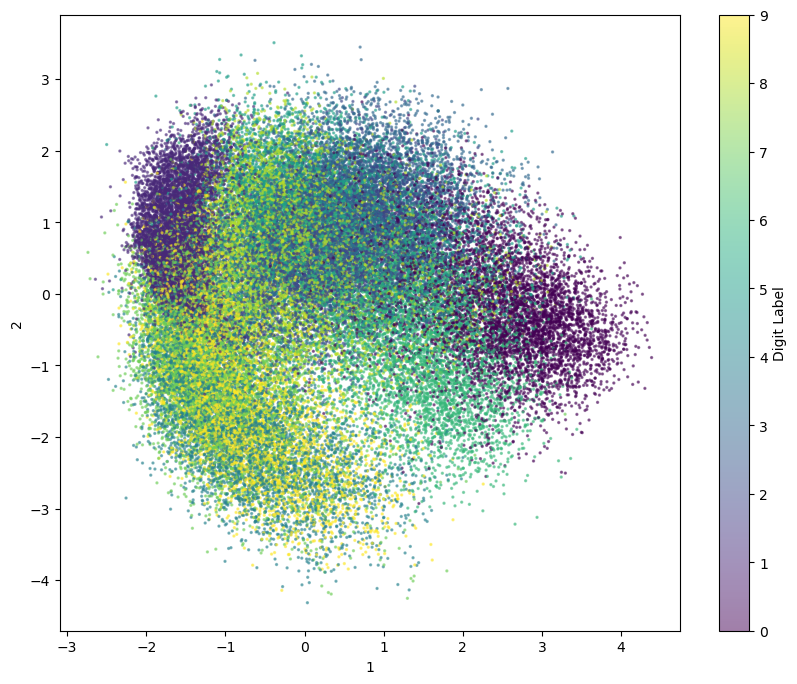

In [46]:
plt.figure(figsize=(10,8))
scatter = plt.scatter(features_2d[:,0],features_2d[:,1], c= true_labels,s=2,alpha = 0.5)
plt.colorbar(scatter, ticks = range(10),label = "Digit Label")
plt.xlabel("1")
plt.ylabel("2")
plt.show()


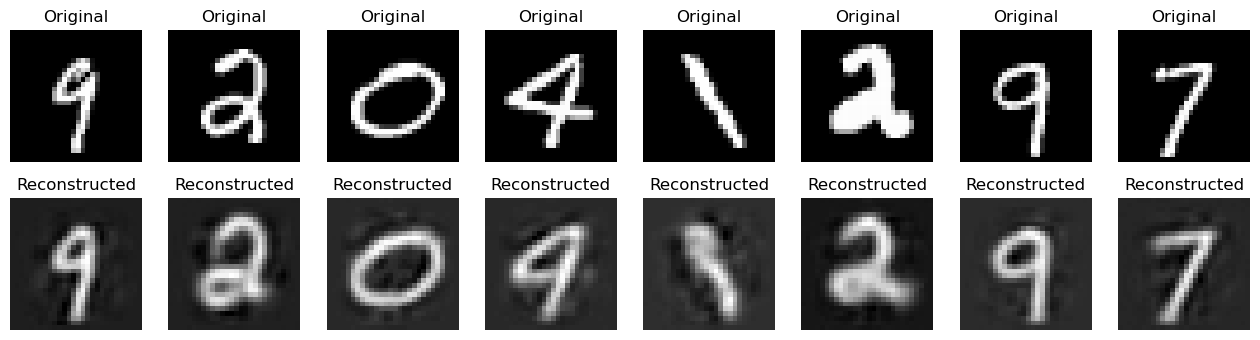

In [48]:
import matplotlib.pyplot as plt

model.eval()

images, _ = next(iter(loaded_set))

with torch.no_grad():
    _, reconstructed = model(images)

images = images.squeeze().numpy()
reconstructed = reconstructed.view(-1, 28, 28).numpy()


n = 8
plt.figure(figsize=(16, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()